Text(0, 0.5, 'Throughput (mb/s)')

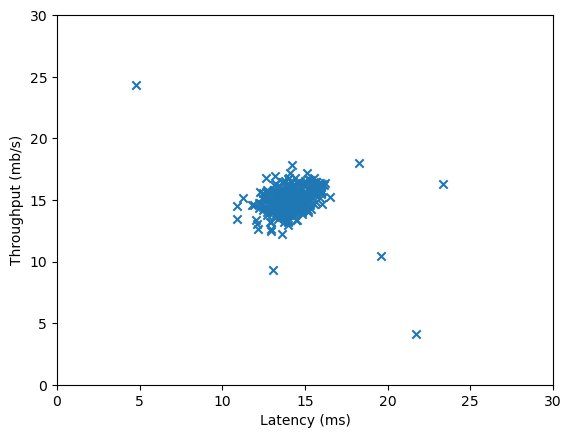

In [16]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.io import loadmat
import sys

mat = loadmat("ex8data1.mat")
X = mat["X"]
Xval = mat["Xval"]
yval = mat["yval"]

plt.scatter(X[:, 0], X[:, 1], marker="x")
plt.xlim(0, 30)
plt.ylim(0, 30)
plt.xlabel("Latency (ms)")
plt.ylabel("Throughput (mb/s)")

Text(0, 0.5, 'Throughput (mb/s)')

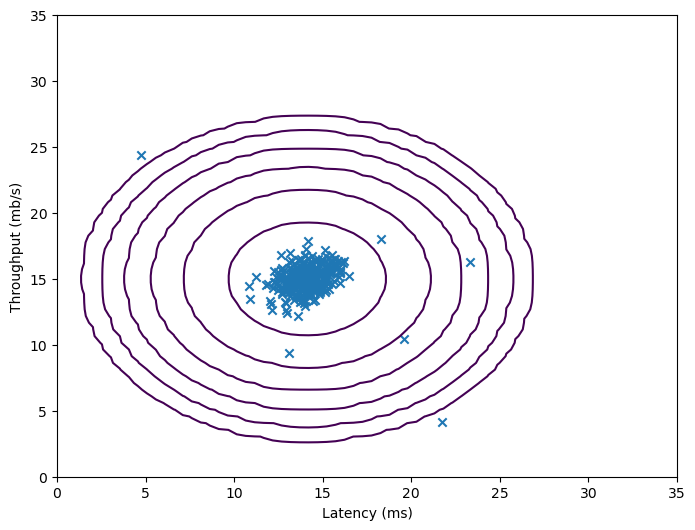

In [2]:
def estimateGaussian(X):
    m = X.shape[0]
    sum_ = np.sum(X, axis=0)
    mu = 1 / m * sum_
    var = 1 / m * np.sum((X - mu) ** 2, axis=0)
    return mu, var

mu, sigma2 = estimateGaussian(X)

def multivariateGaussian(X, mu, sigma2):
    k = len(mu)
    sigma2 = np.diag(sigma2)
    X = X - mu.T
    p = 1 / ((2 * np.pi) ** (k / 2) * np.linalg.det(sigma2) ** 0.5) * np.exp(
        -0.5 * np.sum(X @ np.linalg.inv(sigma2) * X, axis=1)
    )
    return p

p = multivariateGaussian(X, mu, sigma2)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], marker="x")
X1, X2 = np.meshgrid(np.linspace(0, 35, num=70), np.linspace(0, 35, num=70))
p2 = multivariateGaussian(np.hstack((X1.flatten()[:, np.newaxis], X2.flatten()[:, np.newaxis])), mu, sigma2)
contour_levels = np.logspace(-20, 0, num=7)
plt.contour(X1, X2, p2.reshape(X1.shape), levels=contour_levels)
plt.xlim(0, 35)
plt.ylim(0, 35)
plt.xlabel("Latency (ms)")
plt.ylabel("Throughput (mb/s)")


Best epsilon found using cross-validation: 8.990852779269495e-05
Best F1 on Cross Validation Set: 0.8750000000000001


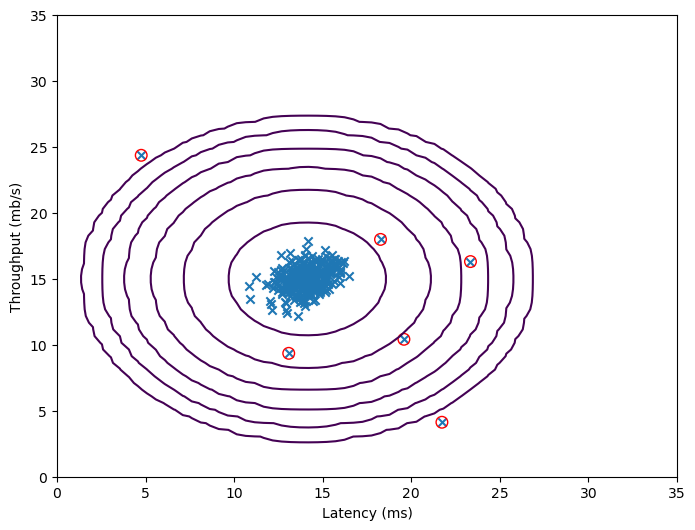

In [3]:
def selectThreshold(yval, pval):
    best_epsilon = 0
    best_F1 = 0
    stepsize = (max(pval) - min(pval)) / 1000
    epsilon_range = np.arange(pval.min(), pval.max(), stepsize)
    for epsilon in epsilon_range:
        predictions = (pval < epsilon)[:, np.newaxis]
        tp = np.sum(np.logical_and(predictions == 1, yval == 1))
        fp = np.sum(np.logical_and(predictions == 1, yval == 0))
        fn = np.sum(np.logical_and(predictions == 0, yval == 1))
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        F1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        if F1 > best_F1:
            best_F1 = F1
            best_epsilon = epsilon
    return best_epsilon, best_F1

pval = multivariateGaussian(Xval, mu, sigma2)
epsilon, F1 = selectThreshold(yval, pval)
print("Best epsilon found using cross-validation:", epsilon)
print("Best F1 on Cross Validation Set:", F1)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], marker="x")
X1, X2 = np.meshgrid(np.linspace(0, 35, num=70), np.linspace(0, 35, num=70))
p2 = multivariateGaussian(np.hstack((X1.flatten()[:, np.newaxis], X2.flatten()[:, np.newaxis])), mu, sigma2)
contour_levels = np.logspace(-20, 0, num=7)
plt.contour(X1, X2, p2.reshape(X1.shape), levels=contour_levels)
outliers = np.nonzero(p < epsilon)[0]
plt.scatter(X[outliers, 0], X[outliers, 1], marker="o", facecolors="none", edgecolors="r", s=70)
plt.xlim(0, 35)
plt.ylim(0, 35)
plt.xlabel("Latency (ms)")
plt.ylabel("Throughput (mb/s)")

plt.show()


In [4]:
mat2 = loadmat("ex8data2.mat")
X2 = mat2["X"]
Xval2 = mat2["Xval"]
yval2 = mat2["yval"]
# compute the mean and variance
mu2, sigma2_2 = estimateGaussian(X2)
# Training set
p3 = multivariateGaussian(X2, mu2, sigma2_2)
# cross-validation set
pval2 = multivariateGaussian(Xval2, mu2, sigma2_2)
# Find the best threshold
epsilon2, F1_2 = selectThreshold(yval2, pval2)
print("Best epsilon found using cross-validation:",epsilon2)
print("Best F1 on Cross Validation Set:",F1_2)
print("# Outliers found:",np.sum(p3<epsilon2))

Best epsilon found using cross-validation: 1.3772288907613575e-18
Best F1 on Cross Validation Set: 0.6153846153846154
# Outliers found: 117


In [5]:
mat3 = loadmat("ex8_movies.mat")
mat4 = loadmat("ex8_movieParams.mat")
Y = mat3["Y"] # 1682 X 943 matrix, containing ratings (1-5) of 1682 movies on 943 user
R = mat3["R"] # 1682 X 943 matrix, where R(i,j) = 1 if and only if user j give rating to movie i
X = mat4["X"] # 1682 X 10 matrix , num_movies X num_features matrix of movie features
Theta = mat4["Theta"] # 943 X 10 matrix, num_users X num_features matrix of user features
# Compute average rating 
print("Average rating for movie 1 (Toy Story):",np.sum(Y[0,:]*R[0,:])/np.sum(R[0,:]),"/5")

Average rating for movie 1 (Toy Story): 3.8783185840707963 /5


Text(0, 0.5, 'Movies')

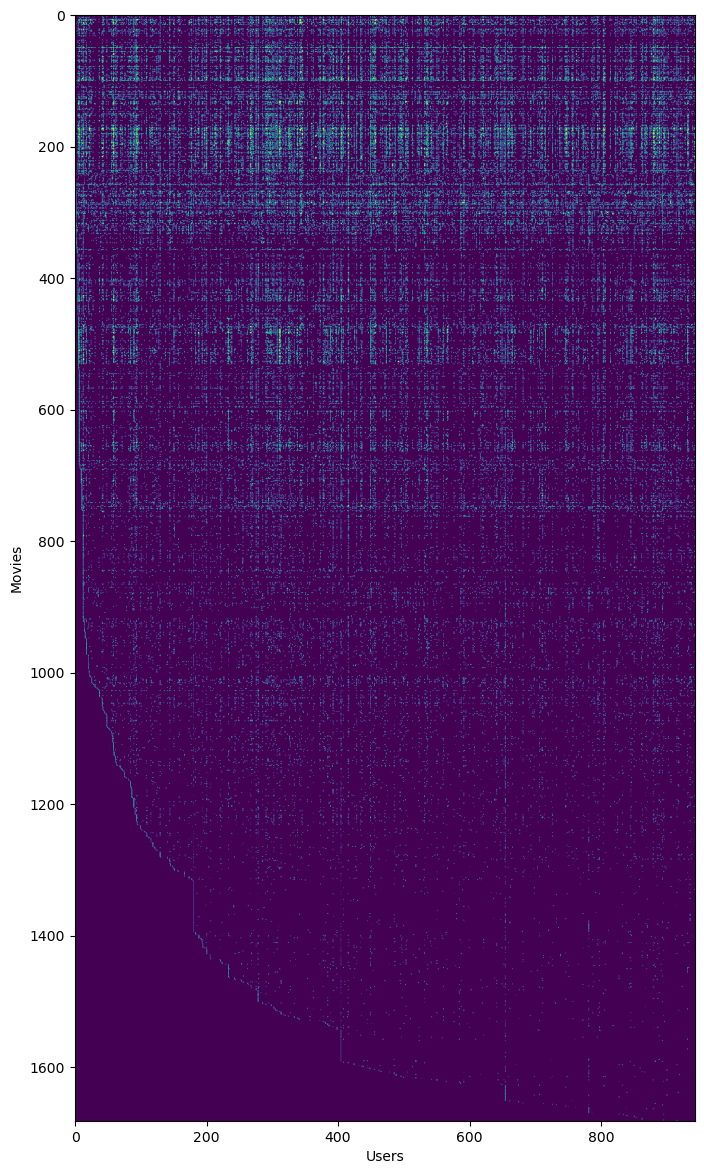

In [6]:
plt.figure(figsize=(8,16))
plt.imshow(Y)
plt.xlabel("Users")
plt.ylabel("Movies")

In [7]:
def  cofiCostFunc(params, Y, R, num_users, num_movies, num_features, Lambda):
    """
    Returns the cost and gradient for the collaborative filtering problem
    """
    
    # Unfold the params
    X = params[:num_movies*num_features].reshape(num_movies,num_features)
    Theta = params[num_movies*num_features:].reshape(num_users,num_features)
    
    predictions =  X @ Theta.T
    err = (predictions - Y)
    J = 1/2 * np.sum((err**2) * R)
    
    #compute regularized cost function
    reg_X =  Lambda/2 * np.sum(Theta**2)
    reg_Theta = Lambda/2 *np.sum(X**2)
    reg_J = J + reg_X + reg_Theta
    
    # Compute gradient
    X_grad = err*R @ Theta
    Theta_grad = (err*R).T @ X
    grad = np.append(X_grad.flatten(),Theta_grad.flatten())
    
    # Compute regularized gradient
    reg_X_grad = X_grad + Lambda*X
    reg_Theta_grad = Theta_grad + Lambda*Theta
    reg_grad = np.append(reg_X_grad.flatten(),reg_Theta_grad.flatten())
    
    return J, grad, reg_J, reg_grad

# Reduce the data set size to run faster
num_users, num_movies, num_features = 4,5,3
X_test = X[:num_movies,:num_features]
Theta_test= Theta[:num_users,:num_features]
Y_test = Y[:num_movies,:num_users]
R_test = R[:num_movies,:num_users]
params = np.append(X_test.flatten(),Theta_test.flatten())
# Evaluate cost function
J, grad = cofiCostFunc(params, Y_test, R_test, num_users, num_movies, num_features, 0)[:2]
print("Cost at loaded parameters:",J)
J2, grad2 = cofiCostFunc(params, Y_test, R_test, num_users, num_movies, num_features, 1.5)[2:]
print("Cost at loaded parameters (lambda = 1.5):",J2)

Cost at loaded parameters: 22.224603725685675
Cost at loaded parameters (lambda = 1.5): 31.34405624427422


In [8]:
# load movie list
movieList = open("movie_ids.txt","r").read().split("\n")[:-1]
# see movie list
np.set_printoptions(threshold=sys.maxsize)
movieList

['1 Toy Story (1995)',
 '2 GoldenEye (1995)',
 '3 Four Rooms (1995)',
 '4 Get Shorty (1995)',
 '5 Copycat (1995)',
 '6 Shanghai Triad (Yao a yao yao dao waipo qiao) (1995)',
 '7 Twelve Monkeys (1995)',
 '8 Babe (1995)',
 '9 Dead Man Walking (1995)',
 '10 Richard III (1995)',
 '11 Seven (Se7en) (1995)',
 '12 Usual Suspects, The (1995)',
 '13 Mighty Aphrodite (1995)',
 '14 Postino, Il (1994)',
 "15 Mr. Holland's Opus (1995)",
 '16 French Twist (Gazon maudit) (1995)',
 '17 From Dusk Till Dawn (1996)',
 '18 White Balloon, The (1995)',
 "19 Antonia's Line (1995)",
 '20 Angels and Insects (1995)',
 '21 Muppet Treasure Island (1996)',
 '22 Braveheart (1995)',
 '23 Taxi Driver (1976)',
 '24 Rumble in the Bronx (1995)',
 '25 Birdcage, The (1996)',
 '26 Brothers McMullen, The (1995)',
 '27 Bad Boys (1995)',
 '28 Apollo 13 (1995)',
 '29 Batman Forever (1995)',
 '30 Belle de jour (1967)',
 '31 Crimson Tide (1995)',
 '32 Crumb (1994)',
 '33 Desperado (1995)',
 '34 Doom Generation, The (1995)',
 '35

In [9]:
# Initialize my ratings
my_ratings = np.zeros((1682,1))
# Create own ratings
my_ratings[0] = 4 
my_ratings[97] = 2
my_ratings[6] = 3
my_ratings[11]= 5
my_ratings[53] = 4
my_ratings[63]= 5
my_ratings[65]= 3
my_ratings[68] = 5
my_ratings[82]= 4
my_ratings[225] = 5
my_ratings[354]= 5
print("New user ratings:\n")
for i in range(len(my_ratings)):
    if my_ratings[i]>0:
        print("Rated",int(my_ratings[i]),"for index",movieList[i])

New user ratings:

Rated 4 for index 1 Toy Story (1995)
Rated 3 for index 7 Twelve Monkeys (1995)
Rated 5 for index 12 Usual Suspects, The (1995)
Rated 4 for index 54 Outbreak (1995)
Rated 5 for index 64 Shawshank Redemption, The (1994)
Rated 3 for index 66 While You Were Sleeping (1995)
Rated 5 for index 69 Forrest Gump (1994)
Rated 4 for index 83 Much Ado About Nothing (1993)
Rated 2 for index 98 Silence of the Lambs, The (1991)
Rated 5 for index 226 Die Hard 2 (1990)
Rated 5 for index 355 Sphere (1998)


Text(0.5, 1.0, 'Cost function using Gradient Descent')

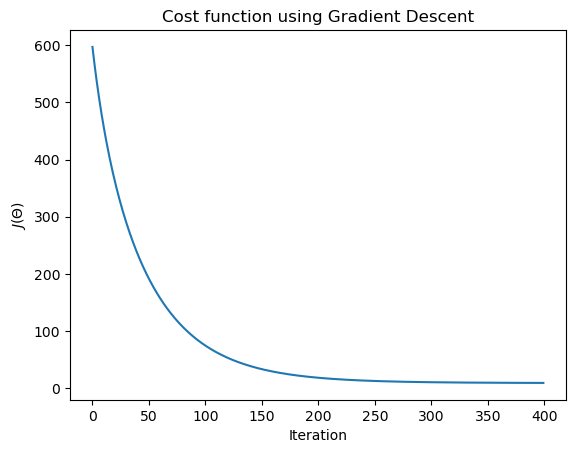

In [10]:
def normalizeRatings(Y, R):
    """
    Normalize the ratings by subtracting the mean rating of each movie (Ymean).
    """
    Ymean = np.zeros((Y.shape[0], 1))
    Ynorm = np.zeros(Y.shape)
    
    for i in range(Y.shape[0]):
        idx = np.where(R[i, :] == 1)[0]
        Ymean[i] = np.mean(Y[i, idx])
        Ynorm[i, idx] = Y[i, idx] - Ymean[i]
    
    return Ynorm, Ymean

def gradientDescent(initial_parameters, Y, R, num_users, num_movies, num_features, alpha, num_iters, Lambda):
    """
    Perform gradient descent to learn the parameters (Theta, X).
    """
    X = initial_parameters[:num_movies * num_features].reshape(num_movies, num_features)
    Theta = initial_parameters[num_movies * num_features:].reshape(num_users, num_features)
    
    J_history = []
    
    for i in range(num_iters):
        params = np.append(X.flatten(), Theta.flatten())
        cost, grad = cofiCostFunc(params, Y, R, num_users, num_movies, num_features, Lambda)[2:]
        
        X_grad = grad[:num_movies * num_features].reshape(num_movies, num_features)
        Theta_grad = grad[num_movies * num_features:].reshape(num_users, num_features)
        
        X = X - alpha * X_grad
        Theta = Theta - alpha * Theta_grad
        
        J_history.append(cost)
    
    paramsFinal = np.append(X.flatten(), Theta.flatten())
    
    return paramsFinal, J_history

# Assuming you have some values for my_ratings, Y, and R
my_ratings = np.array([1, 0, 0, 1, 0])
Y = np.array([[4, 5, 0, 0, 1],
              [0, 3, 4, 0, 0],
              [0, 0, 0, 2, 3],
              [4, 0, 0, 0, 0],
              [0, 2, 3, 0, 0]])
R = np.array([[1, 1, 0, 0, 1],
              [0, 1, 1, 0, 0],
              [0, 0, 0, 1, 1],
              [1, 0, 0, 0, 0],
              [0, 1, 1, 0, 0]])

# Concatenate my_ratings to Y and R
Y = np.hstack((my_ratings[:, np.newaxis], Y))
R = np.hstack((my_ratings[:, np.newaxis] != 0, R))

# Normalize Ratings
Ynorm, Ymean = normalizeRatings(Y, R)

# Set initial Parameters (Theta, X)
num_users = Y.shape[1]
num_movies = Y.shape[0]
num_features = 10
X = np.random.randn(num_movies, num_features)
Theta = np.random.randn(num_users, num_features)
initial_parameters = np.append(X.flatten(), Theta.flatten())
Lambda = 10

# Optimize parameters using Gradient Descent
paramsFinal, J_history = gradientDescent(initial_parameters, Ynorm, R, num_users, num_movies, num_features, 0.001, 400, Lambda)



plt.plot(J_history)
plt.xlabel("Iteration")
plt.ylabel("$J(\Theta)$")
plt.title("Cost function using Gradient Descent")

In [21]:
# Set the number of movies to recommend
num_recommendations = 10

# Unfold parameters
X = paramsFinal[:num_movies * num_features].reshape(num_movies, num_features)
Theta = paramsFinal[num_movies * num_features:].reshape(num_users, num_features)

# Predict rating
p = X @ Theta.T
my_predictions = p[:, 0][:, np.newaxis] + Ymean

import pandas as pd

# Create movie list for my_predictions
my_movie_list = np.array(movieList)[:num_movies]

# Create DataFrame with predictions and movie list
df = pd.DataFrame({"Predicted Rating": my_predictions.flatten(), "Movie": my_movie_list})
df.sort_values(by=["Predicted Rating"], ascending=False, inplace=True)
df.reset_index(drop=True, inplace=True)

print("Top recommendations for you:\n")
for i in range(min(num_recommendations, len(df))):
    print("Predicting rating", round(float(df["Predicted Rating"][i]), 1), "for index", i, df["Movie"][i])


Top recommendations for you:

Predicting rating 3.5 for index 0 2 GoldenEye (1995)
Predicting rating 2.7 for index 1 1 Toy Story (1995)
Predicting rating 2.5 for index 2 3 Four Rooms (1995)
Predicting rating 2.5 for index 3 5 Copycat (1995)
Predicting rating 2.5 for index 4 4 Get Shorty (1995)
